# Inference & Evaluation

Load trained models and evaluate with detailed metrics and visualizations.

In [1]:
import sys; sys.path.insert(0, '..')
from src import suppress_logs; suppress_logs()

import torch
torch.set_float32_matmul_precision('medium')

import numpy as np

from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report
from pytorch_lightning import seed_everything
from src.data import GestureDataModule
from src.hub import get_model
from src.models import BiLSTMModule, TransformerModule
from src.visualization import plot_confusion_matrices, print_results_table

/home/marcantoniolopez/Documenti/github/dylem-grid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
DATA_PATH = None  # Auto-download from HuggingFace
TEST_SPLIT = 0.2
SEED = 42

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Seed set to 42


Device: cuda


## Load Data & Models

In [3]:
dm = GestureDataModule(data_path=DATA_PATH, test_split=TEST_SPLIT, seed=SEED)
dm.setup()
print(f'Classes: {dm.class_names}')
print(f'Test samples: {len(dm.test_dataset)}')

Classes: [np.str_('air_quotes'), np.str_('finger_wagging'), np.str_('waving'), np.str_('zoom')]
Test samples: 80


In [4]:
models = {}

# Load models from local checkpoints
try:
    models['bilstm'] = BiLSTMModule.load_from_checkpoint('../models/checkpoints/bilstm_best.ckpt').to(device).eval()
    print('✓ BiLSTM loaded from local checkpoint')
except Exception as e:
    print(f'✗ BiLSTM: {e}')

try:
    models['transformer'] = TransformerModule.load_from_checkpoint('../models/checkpoints/transformer_best.ckpt').to(device).eval()
    print('✓ Transformer loaded from local checkpoint')
except Exception as e:
    print(f'✗ Transformer: {e}')

✓ BiLSTM loaded from local checkpoint
✓ Transformer loaded from local checkpoint


## Run Inference

In [5]:
predictions = {}
results = {}

for name, model in models.items():
    preds, targets = [], []
    with torch.no_grad():
        for x, y in dm.test_dataloader():
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.numpy())
    
    predictions[name] = (preds, targets)
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='macro')
    results[name] = {'accuracy': acc, 'f1': f1}
    print(f'{name.upper()}: Acc={acc:.4f}, F1={f1:.4f}')

BILSTM: Acc=0.9750, F1=0.9750
TRANSFORMER: Acc=0.9500, F1=0.9500


## Results

In [6]:
print_results_table(results)


RESULTS SUMMARY
Model           Accuracy        F1              Epochs
------------------------------------------------------------
BILSTM          0.9750  0.9749921826141339
TRANSFORMER     0.9500  0.9499542124542124


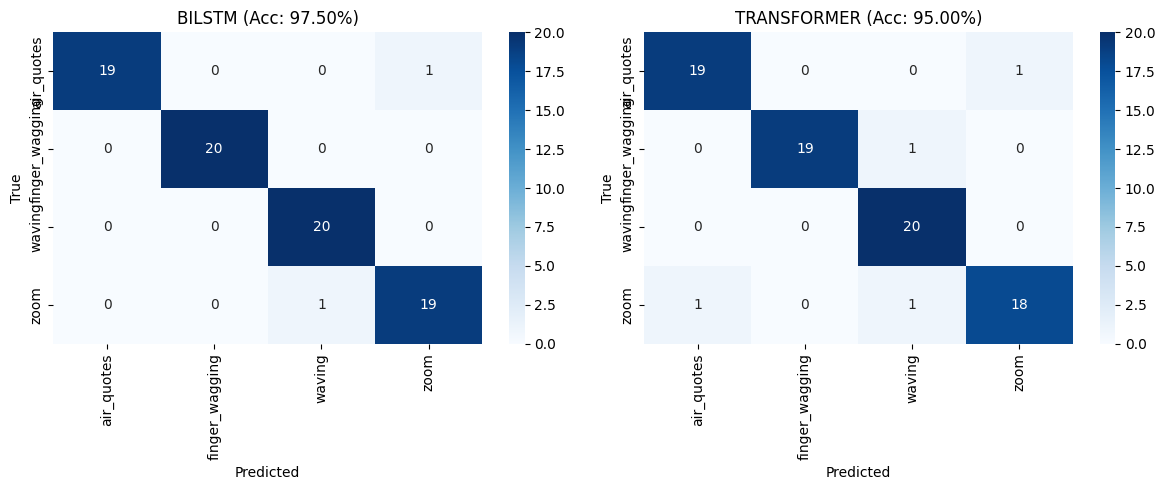

In [7]:
fig = plot_confusion_matrices(predictions, dm.class_names)
Path('../plots').mkdir(exist_ok=True)
fig.savefig('../plots/confusion_matrices.png', dpi=150)

## Classification Reports

In [8]:
for name, (preds, targets) in predictions.items():
    print(f'\n{"="*60}\n{name.upper()} Classification Report\n{"="*60}')
    print(classification_report(targets, preds, target_names=dm.class_names))


BILSTM Classification Report
                precision    recall  f1-score   support

    air_quotes       1.00      0.95      0.97        20
finger_wagging       1.00      1.00      1.00        20
        waving       0.95      1.00      0.98        20
          zoom       0.95      0.95      0.95        20

      accuracy                           0.97        80
     macro avg       0.98      0.98      0.97        80
  weighted avg       0.98      0.97      0.97        80


TRANSFORMER Classification Report
                precision    recall  f1-score   support

    air_quotes       0.95      0.95      0.95        20
finger_wagging       1.00      0.95      0.97        20
        waving       0.91      1.00      0.95        20
          zoom       0.95      0.90      0.92        20

      accuracy                           0.95        80
     macro avg       0.95      0.95      0.95        80
  weighted avg       0.95      0.95      0.95        80



## Per-Class Comparison

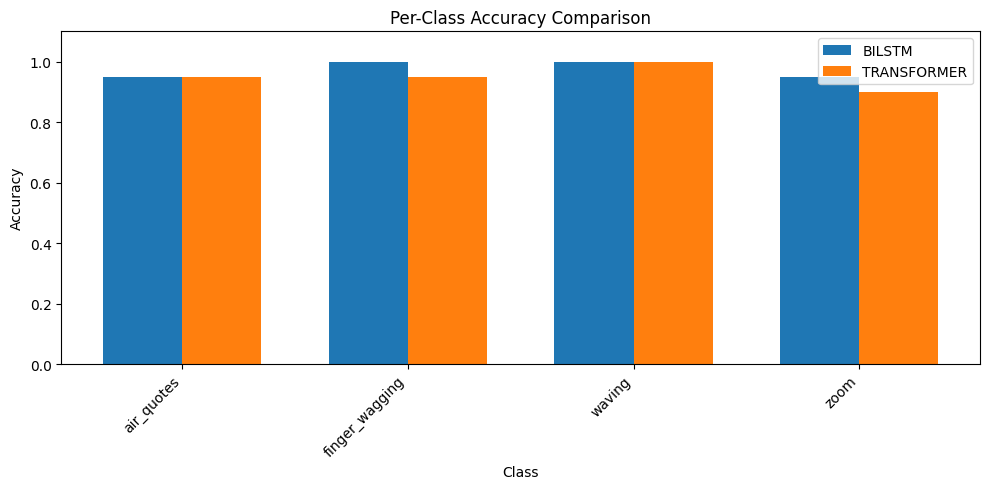

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dm.class_names))
width = 0.35

for i, (name, (preds, targets)) in enumerate(predictions.items()):
    cm = confusion_matrix(targets, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    ax.bar(x + i * width, per_class_acc, width, label=name.upper())

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy Comparison')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(dm.class_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../plots/per_class_comparison.png', dpi=150)